In [1]:
# View and modify the working path
import os
from google.colab import drive

# View current working directory
print("Current Working Directory:", os.getcwd())

# Mount Google Drive
drive.mount('/content/gdrive')

# Change working directory to your file position
path = "/content/gdrive/My Drive/GroupProject"
os.chdir(path)

# Confirm the change
print("Working Directory:", os.getcwd())

Current Working Directory: /content
Mounted at /content/gdrive
Working Directory: /content/gdrive/My Drive/GroupProject


In [ ]:
#Process text data and initialize embeddings for deep learning tasks
import gensim
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

readm_balanced=pd.read_csv('gen_readm_balanced.csv')
#print(readm_balanced.head())
#Load pre-trained word2vec model
pmc_word2vec_path = 'PubMed-and-PMC-w2v.bin'
word2vec_model = gensim.models.KeyedVectors.load_word2vec_format(pmc_word2vec_path, binary=True)

#Preprocess and tokenize 'cleaned_text' column
texts = readm_balanced['cleaned_text'].values

#Use Tokenizer to tokenize and create word index
tokenizer = Tokenizer()
tokenizer.fit_on_texts(texts)
word_index = tokenizer.word_index

#Convert texts to sequences of word indices
sequences = tokenizer.texts_to_sequences(texts)

#Define padding length (e.g., max 100 words per sequence)
MAX_SEQUENCE_LENGTH = 200

#Pad sequences to the same length
data_padded = pad_sequences(sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post')
# Convert data_padded to DataFrame and save to CSV
#data_padded_df = pd.DataFrame(data_padded)
#data_padded_df.to_csv('data_padded_gen.csv', index=False)

#Initialize embedding matrix
EMBEDDING_DIM = word2vec_model.vector_size  # Automatically set to 200 based on your model
embedding_matrix = np.zeros((len(word_index) + 1, EMBEDDING_DIM))

for word, i in word_index.items():
    if word in word2vec_model:
        #Use the pre-trained word2vec vector with the correct size
        embedding_matrix[i] = word2vec_model[word]
    else:
        #Randomly initialize words not in the pre-trained model
        embedding_matrix[i] = np.random.normal(0, np.std(embedding_matrix), EMBEDDING_DIM)
# Convert embedding_matrix to DataFrame and save to CSV
#embedding_matrix_df = pd.DataFrame(embedding_matrix)
#embedding_matrix_df.to_csv('embedding_matrix_gen.csv', index=False)

In [ ]:
#Generate training and test sets
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.model_selection import train_test_split


# Convert data_padded and labels to tensors
data_padded = torch.tensor(data_padded, dtype=torch.long)  # Sequences of word indices
readm_balanced['gen_readm_converted'] = readm_balanced['gen_readm'].map({'positive': 1, 'negative': 0})
# Change the dtype to torch.long
labels = torch.tensor(readm_balanced['gen_readm_converted'].values, dtype=torch.long)  # Binary labels

# Define a custom Dataset class
class ReadmissionDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

# Instantiate the Dataset
dataset = ReadmissionDataset(data_padded, labels)

# Split dataset into train/test using sklearn's train_test_split
train_indices, test_indices = train_test_split(range(len(dataset)), test_size=0.1, random_state=903965310, stratify=labels)

# Create subsets for train/test
train_dataset = torch.utils.data.Subset(dataset, train_indices)
test_dataset = torch.utils.data.Subset(dataset, test_indices)

# Create DataLoaders for train and test sets
batch_size = 32
dataloader_train = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
dataloader_test = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
#Create the CNN network with three kernel sizes
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from sklearn.model_selection import KFold

class ReadminAnalysisCNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, embedding_matrix=None):
        super(ReadminAnalysisCNN, self).__init__()

        self.embedding = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embedding_dim, padding_idx=0)

        # If embedding_matrix is provided, initialize the weights
        if embedding_matrix is not None:
            embedding_matrix = torch.tensor(embedding_matrix, dtype=torch.float)
            self.embedding.weight = nn.Parameter(embedding_matrix, requires_grad=True)

        self.conv1d_1 = nn.Conv1d(in_channels=embedding_dim, out_channels=128, kernel_size=1, padding=0)
        self.conv1d_2 = nn.Conv1d(in_channels=embedding_dim, out_channels=128, kernel_size=2, padding=1)
        self.conv1d_3 = nn.Conv1d(in_channels=embedding_dim, out_channels=128, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(128 * 3, 2)

    def forward(self, x):
        x = self.embedding(x)
        x = x.permute(0, 2, 1)

        x1 = F.relu(self.conv1d_1(x))
        x1 = F.max_pool1d(x1, kernel_size=x1.size(2)).squeeze(2)

        x2 = F.relu(self.conv1d_2(x))
        x2 = F.max_pool1d(x2, kernel_size=x2.size(2)).squeeze(2)

        x3 = F.relu(self.conv1d_3(x))
        x3 = F.max_pool1d(x3, kernel_size=x3.size(2)).squeeze(2)

        x = torch.cat((x1, x2, x3), dim=1)
        x = self.fc1(x)
        return x



In [ ]:
#Train the model and save the best one
torch.manual_seed(903965310)
# Prepare cross-validation
k_folds = 5
kfold = KFold(n_splits=k_folds, shuffle=True, random_state=903965310)
best_model = None
best_val_accuracy = 0
vocab_size = len(word_index) + 1
embedding_dim = word2vec_model.vector_size 
# Training loop
for fold, (train_idx, val_idx) in enumerate(kfold.split(train_dataset)):
    print(f'Fold {fold + 1}/{k_folds}')

    # Create new model instance
    CNN_model = ReadminAnalysisCNN(vocab_size, embedding_dim)

    # Define loss and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(CNN_model.parameters(), lr=0.001)

    # Create training and validation dataloaders for this fold
    train_sampler = torch.utils.data.SubsetRandomSampler(train_idx)
    val_sampler = torch.utils.data.SubsetRandomSampler(val_idx)
    train_loader = torch.utils.data.DataLoader(dataloader_train.dataset, sampler=train_sampler, batch_size=32)
    val_loader = torch.utils.data.DataLoader(dataloader_train.dataset, sampler=val_sampler, batch_size=32)

    # Training for multiple epochs
    for epoch in range(5):  # Adjust the number of epochs as needed
        CNN_model.train()
        running_loss = 0.0
        for notes, labels in train_loader:
            notes, labels = notes, labels
            optimizer.zero_grad()
            outputs = CNN_model(notes)

            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    # Validation step
    CNN_model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for notes, labels in val_loader:
            notes, labels = notes, labels
            outputs = CNN_model(notes)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    # Calculate fold accuracy
    fold_accuracy = correct / total
    print(f'Fold {fold + 1}, Validation Accuracy: {fold_accuracy:.4f}')

    # Save the best model
    if fold_accuracy > best_val_accuracy:
        best_val_accuracy = fold_accuracy
        best_model = CNN_model.state_dict()  # Save the model's state dict

Fold 1/5
Fold 1, Validation Accuracy: 0.6575
Fold 2/5
Fold 2, Validation Accuracy: 0.6583
Fold 3/5
Fold 3, Validation Accuracy: 0.6552
Fold 4/5
Fold 4, Validation Accuracy: 0.6246
Fold 5/5
Fold 5, Validation Accuracy: 0.6533


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Load the best model for testing
CNN_model.load_state_dict(best_model)
CNN_model.eval()

# Evaluate on test set
all_labels = []
all_predictions = []
with torch.no_grad():
    for notes, labels in dataloader_test:
        notes, labels = notes, labels
        outputs = CNN_model(notes)
        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

# Calculate metrics
accuracy = accuracy_score(all_labels, all_predictions)
precision = precision_score(all_labels, all_predictions)
recall = recall_score(all_labels, all_predictions)
f1 = f1_score(all_labels, all_predictions)


print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1 Score: {f1:.3f}")
print(f"Test Accuracy: {accuracy:.4f}")

Precision: 0.641
Recall: 0.686
F1 Score: 0.663
Test Accuracy: 0.6516


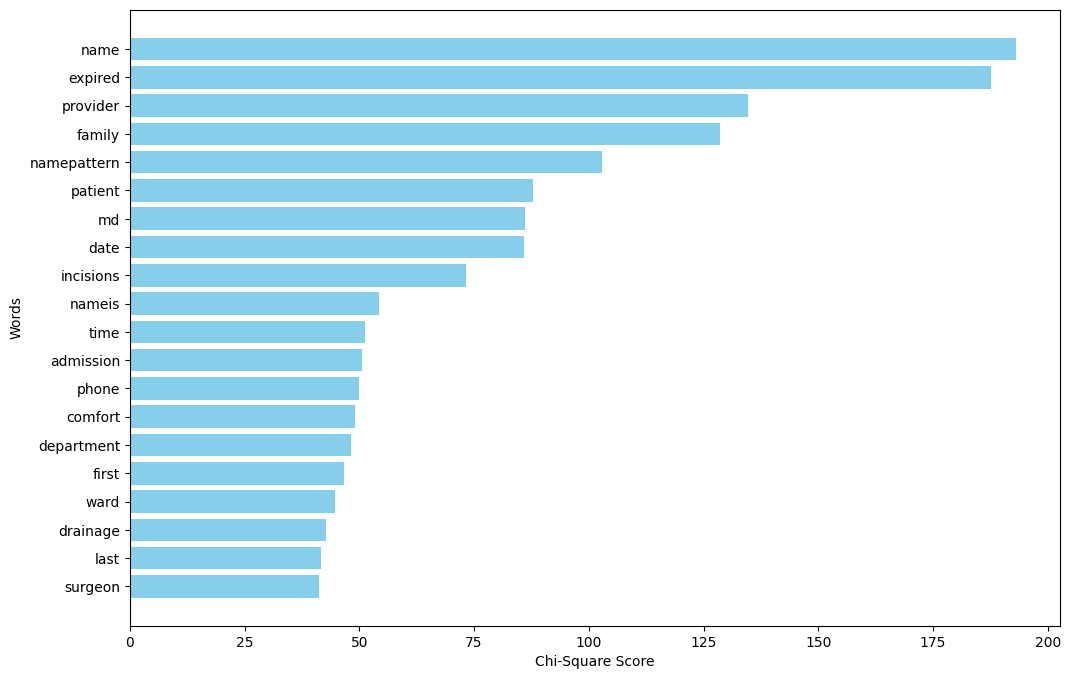

In [ ]:
import numpy as np
import pandas as pd
import torch
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_selection import chi2
import matplotlib.pyplot as plt

# Step 1: Filter Correct Predictions
correct_indices = [i for i, (true, pred) in enumerate(zip(all_labels, all_predictions)) if true == pred]
correct_texts = [dataloader_test.dataset[i][0].numpy() for i in correct_indices]  # Convert tensors to NumPy arrays
correct_labels = [all_labels[i] for i in correct_indices]

# Step 2: Map indices back to words using tokenizer
reverse_word_index = {v: k for k, v in tokenizer.word_index.items()}  # Reverse mapping
correct_texts_words = [
    " ".join([reverse_word_index.get(word_idx, "<UNK>") for word_idx in text if word_idx != 0])  # Ignore padding (index 0)
    for text in correct_texts
]

# Step 3: Vectorize the Text
vectorizer = CountVectorizer(max_features=5000)  # Adjust max_features if needed
X = vectorizer.fit_transform(correct_texts_words)
y = np.array(correct_labels)

# Step 4: Apply Chi-Square Scoring
chi2_scores, p_values = chi2(X, y)

# Get feature names and scores
feature_names = vectorizer.get_feature_names_out()
feature_scores = list(zip(feature_names, chi2_scores))

# Sort by score and take top 20
top_features = sorted(feature_scores, key=lambda x: x[1], reverse=True)[:20]

# Prepare data for plotting
top_words = [x[0] for x in top_features]
top_scores = [x[1] for x in top_features]

# Step 5: Plot Bar Chart
plt.figure(figsize=(12, 8))
plt.barh(top_words, top_scores, color="skyblue")
plt.xlabel("Chi-Square Score")
plt.ylabel("Words")
#plt.title("Top 20 Words by Chi-Square Feature Scoring")
plt.gca().invert_yaxis()  # Invert y-axis for better readability
plt.show()


In [ ]:
import pandas as pd

# Prepare containers for counts
positive_texts = [correct_texts_words[i] for i, label in enumerate(correct_labels) if label == 1]
negative_texts = [correct_texts_words[i] for i, label in enumerate(correct_labels) if label == 0]

# Initialize DataFrame to store results
results = []

# Count occurrences of each top word in positive and negative samples
for word in top_words:
    count_positive = sum(text.split().count(word) for text in positive_texts)
    count_negative = sum(text.split().count(word) for text in negative_texts)
    results.append({"Term": word, "Count in positive samples": count_positive, "Count in negative samples": count_negative})

# Convert to DataFrame and display
results_df = pd.DataFrame(results)

# Sort DataFrame by descending order of term scores
results_df = results_df.sort_values(by="Term", key=lambda x: [top_words.index(term) for term in x])

# Display table
print(results_df)

           Term  Count in positive samples  Count in negative samples
0          name                       1903                       1004
1       expired                          0                        169
2      provider                        211                         22
3        family                          3                        120
4   namepattern                        680                        310
5       patient                        245                        417
6            md                        525                        231
7          date                        228                         57
8     incisions                          5                         79
9        nameis                        146                         37
10         time                        254                        101
11    admission                         42                        125
12        phone                        212                         77
13      comfort     

In [ ]:
#Use TF-IDF to encode the text. Use RandomForest to make predictions
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Load data
readm_balanced = pd.read_csv('readm_30d_balanced.csv')

# Encode labels
X_texts = readm_balanced['cleaned_text']
readm_balanced['readm_30d_converted'] = readm_balanced['readm_30d'].map({'positive': 1, 'negative': 0})
y_labels = readm_balanced['readm_30d_converted']  # Assuming 1 for positive and 0 for negative

# Split into train and test sets (90%-10%)
X_train, X_test, y_train, y_test = train_test_split(X_texts, y_labels, test_size=0.1, random_state=903965310)

# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(max_features=3000)  # Start with all features
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# Feature selection through GridSearch on max_features for RandomForest
param_grid = {'max_features': [1000, 3000]}  # Adjust as necessary
rf_model = RandomForestClassifier(random_state=903965310)
grid_search = GridSearchCV(rf_model, param_grid, scoring='accuracy', cv=4, n_jobs=-1)

# Train the model with GridSearchCV to find the best max_features
grid_search.fit(X_train_tfidf, y_train)
best_rf_model = grid_search.best_estimator_

# Make predictions on the test set
y_pred = best_rf_model.predict(X_test_tfidf)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Best max_features:", grid_search.best_params_['max_features'])

print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1 Score: {f1:.3f}")
print(f"Test Accuracy: {accuracy:.4f}")

Best max_features: 3000
Precision: 0.630
Recall: 0.723
F1 Score: 0.673
Test Accuracy: 0.6580
